# 24RB1003 松澤颯斗

# 課題１

In [65]:
import numpy as np
import matplotlib.pyplot as plt

In [66]:
# 2次元データの生成
s = np.random.rand(100, 1) * 2 * np.pi  # 0から2πの範囲でランダムな値を生成
Z = np.hstack([2*np.cos(s), 3*np.sin(s)])  # 楕円状のデータを生成

# 5次元空間へリフト
P = np.random.randn(2, 5)
X = Z @ P  # 2次元データを5次元空間にリフト

X

array([[-1.1772761 , -1.06475726, -1.91577571,  2.67919102,  0.89104841],
       [-1.66067029, -1.55532966, -1.87251836,  2.93288651,  1.16976033],
       [ 2.66532404,  2.58454875,  1.63263913, -3.30719053, -1.73326549],
       [-2.95135376, -3.03353531,  0.86041412,  0.9407635 ,  1.63904469],
       [-3.50233794, -3.46240373, -1.11601979,  3.29596848,  2.16947475],
       [-2.74505311, -2.83424415,  0.99855761,  0.67277264,  1.50365039],
       [-0.83767774, -0.95725585,  1.7406514 , -1.25919428,  0.30804773],
       [-1.88236994, -1.78119215, -1.83914281,  3.03543351,  1.29616469],
       [ 2.77616486,  2.86437498, -0.97890857, -0.71198012, -1.52394456],
       [-3.774567  , -3.76766969, -0.64088243,  2.97909646,  2.27909308],
       [ 3.77917184,  3.77354523,  0.62177775, -2.96244872, -2.27978497],
       [-3.75468306, -3.78136187, -0.11606273,  2.43158648,  2.21232396],
       [ 0.22920148,  0.35029399, -1.85022236,  1.74581978,  0.060009  ],
       [-1.13859956, -1.02560918, -1.9

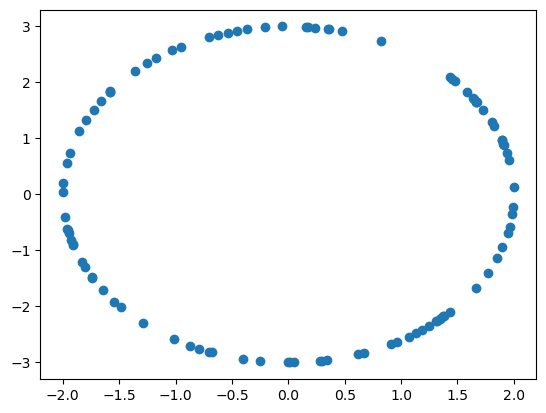

In [67]:
plt.scatter(Z[:, 0], Z[:, 1])

1. 中心化して $M = \frac{1}{m}X^{\top}X$ を計算

In [68]:
# 中心化する
X_centered = X - np.mean(X, axis=0)

# 共分散行列の計算
M = (X_centered.T @ X_centered) / X_centered.shape[0]

M

array([[ 7.05244313,  7.07097429,  0.70897313, -5.06800162, -4.20698396],
       [ 7.07097429,  7.09699097,  0.59521544, -4.96339781, -4.20589559],
       [ 0.70897313,  0.59521544,  1.86882736, -2.34279295, -0.61170591],
       [-5.06800162, -4.96339781, -2.34279295,  5.51173182,  3.21574641],
       [-4.20698396, -4.20589559, -0.61170591,  3.21574641,  2.52941263]])

2. `np.linalg.eigh`で固有値分解

In [69]:
# 固有値分解
eigenvalues, eigenvectors = np.linalg.eigh(M)

eigenvalues, eigenvectors

(array([-6.68336935e-15, -6.52785363e-16,  1.08429718e-15,  3.18431435e+00,
         2.08750916e+01]),
 array([[-0.72638618, -0.20212886,  0.19881658,  0.2527525 , -0.57279593],
        [ 0.66327456, -0.0168113 ,  0.37816467,  0.30104114, -0.57109539],
        [ 0.08010849, -0.64360843,  0.23784953, -0.71500998, -0.10742044],
        [ 0.05242191, -0.66330706,  0.12039751,  0.5735156 ,  0.46244998],
        [-0.1525272 ,  0.32350151,  0.86394183, -0.07301369,  0.34692325]]))

3. 上位2固有ベクトルで射影し2D散布図をプロット

In [70]:
# 上位2固有ベクトルを取得
V = eigenvectors[:, [-1, -2]]  # 固有値の大きい順に上位2つの固有ベクトルを選択
V

array([[-0.57279593,  0.2527525 ],
       [-0.57109539,  0.30104114],
       [-0.10742044, -0.71500998],
       [ 0.46244998,  0.5735156 ],
       [ 0.34692325, -0.07301369]])

In [71]:
# データを上位2次元の空間に射影
X_pca = X_centered @ V  
X_pca

array([[ 2.92761777,  2.34759322],
       [ 3.69403403,  2.17195075],
       [-5.4175196 , -1.36141308],
       [ 4.22550431, -1.73012523],
       [ 6.271523  ,  0.72669319],
       [ 3.80777865, -1.86057267],
       [ 0.25536596, -2.36475032],
       [ 4.03770197,  2.07364091],
       [-4.08750934,  2.09123443],
       [ 6.4422429 ,  0.03652637],
       [-6.6561448 ,  0.23844577],
       [ 6.10593691, -0.6469516 ],
       [ 0.58687772,  2.60757558],
       [ 2.86537157,  2.35955024],
       [ 4.06872011,  2.0640764 ],
       [-5.899614  ,  1.27165147],
       [-3.08532617, -2.11028837],
       [ 5.06560956,  1.67771996],
       [ 5.59714046, -1.0821604 ],
       [ 2.53490176, -2.14774987],
       [ 6.12899165, -0.62033803],
       [-1.49695669,  2.5567191 ],
       [-4.93511005, -1.58382137],
       [-0.20639744,  2.61817506],
       [ 2.47361451,  2.42771138],
       [ 2.34811022,  2.44707358],
       [ 1.27199803, -2.30858766],
       [ 5.56851491,  1.39582345],
       [-3.12385977,

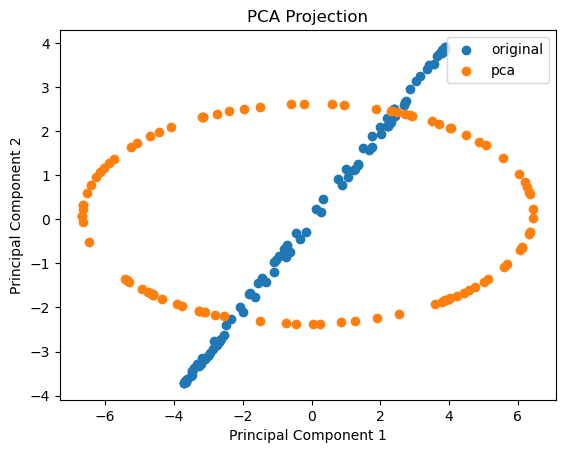

In [72]:
# 射影されたデータをプロット
plt.scatter(X_centered[:, 0], X_centered[:, 1], label='original')
plt.scatter(X_pca[:, 0], X_pca[:, 1], label='pca')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection')
plt.legend()
plt.show()


# 課題２

In [73]:
from sklearn.decomposition import PCA

In [74]:
X_skpca = PCA(n_components=2).fit_transform(X)
X_skpca

array([[-2.92761777, -2.34759322],
       [-3.69403403, -2.17195075],
       [ 5.4175196 ,  1.36141308],
       [-4.22550431,  1.73012523],
       [-6.271523  , -0.72669319],
       [-3.80777865,  1.86057267],
       [-0.25536596,  2.36475032],
       [-4.03770197, -2.07364091],
       [ 4.08750934, -2.09123443],
       [-6.4422429 , -0.03652637],
       [ 6.6561448 , -0.23844577],
       [-6.10593691,  0.6469516 ],
       [-0.58687772, -2.60757558],
       [-2.86537157, -2.35955024],
       [-4.06872011, -2.0640764 ],
       [ 5.899614  , -1.27165147],
       [ 3.08532617,  2.11028837],
       [-5.06560956, -1.67771996],
       [-5.59714046,  1.0821604 ],
       [-2.53490176,  2.14774987],
       [-6.12899165,  0.62033803],
       [ 1.49695669, -2.5567191 ],
       [ 4.93511005,  1.58382137],
       [ 0.20639744, -2.61817506],
       [-2.47361451, -2.42771138],
       [-2.34811022, -2.44707358],
       [-1.27199803,  2.30858766],
       [-5.56851491, -1.39582345],
       [ 3.12385977,

In [75]:
# X_pca と X_skpca が一致している確認
np.allclose(np.abs(X_pca), np.abs(X_skpca)) # PCAは符号が不定なので、絶対値で比較

True

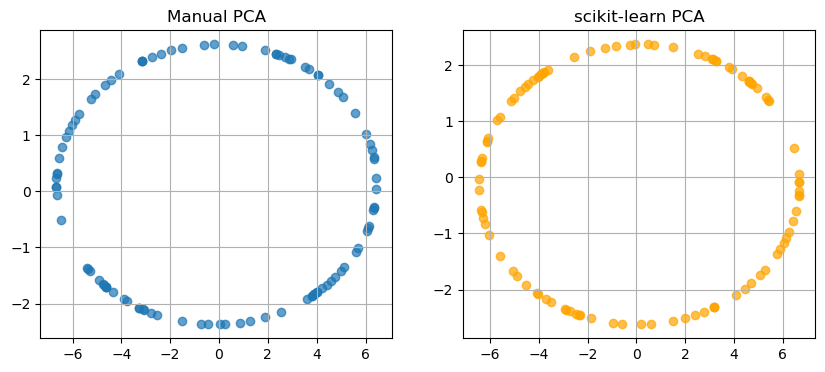

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 手計算のPCA結果
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
axes[0].set_title('Manual PCA')
axes[0].grid(True)

# scikit-learnのPCA結果
axes[1].scatter(X_skpca[:, 0], X_skpca[:, 1], alpha=0.7, color='orange')
axes[1].set_title('scikit-learn PCA')
axes[1].grid(True)

plt.show()

# 課題３

In [77]:
import sklearn

iris = sklearn.datasets.load_iris() # irisデータセットの読み込み
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [78]:
iris.data.shape, iris.target.shape

((150, 4), (150,))

In [79]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [80]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [81]:
# PCAで2次元に射影
iris_pca = PCA(n_components=2).fit_transform(iris.data)
iris_pca

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

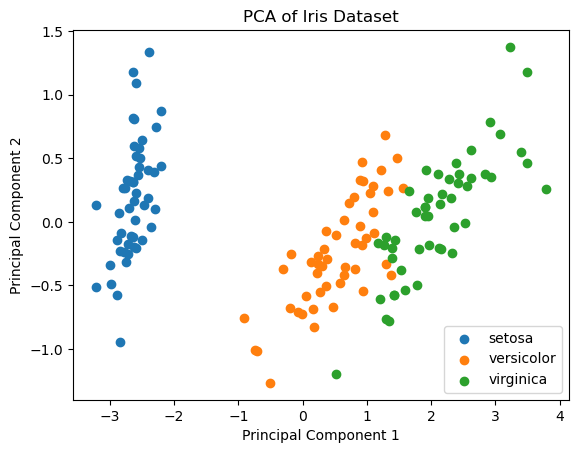

In [82]:
# クラスごとに色分けしてプロット
for target in np.unique(iris.target):
    plt.scatter(iris_pca[iris.target == target, 0], iris_pca[iris.target == target, 1], label=iris.target_names[target])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.legend()
plt.show()

$\text{寄与率} = \frac{\lambda_i}{\sum_{j}\lambda_j}$  

全体の情報のうち主成分が何割を説明しているか

In [83]:
# 寄与率を計算
pca = PCA(n_components=2).fit(iris.data) 
explained_variance_ratio = pca.explained_variance_ratio_ 
explained_variance_ratio # 寄与率

array([0.92461872, 0.05306648])

In [84]:
# どの程度の情報を保持できるか
total_explained_variance = np.sum(explained_variance_ratio)
total_explained_variance

np.float64(0.9776852063187977)

上記のコードより上位2成分で約97.8%の情報を保持できることが確認できた．

# 考察  
PCAがデータの分散を最大化する手法であることを実装を通して理解した．また，irisデータの分析では，元の4次元データを2次元に射影しても寄与率が約97.8%に達し，ほとんどの情報を保持できていることが確認できた．散布図でもクラスごとに分離されており，次元削減の有用性を理解した．

# AI使用について  
Gemini Guided Learningを使用して，PCAや共分散行列や固有値分解に加え，scikit-learnでの実装方法やIrisデータセットのデータの抽出やラベルを用いたプロットについて質問した．AIに直接コードを生成させることはせず，実装の方針や考え方のヒントのみをもらい，それをもとに自身でコードを作成した．なお，プロットなどの実際のコーディング作業においては，GitHub Copilotの自動補完を補助的に活用してコードを生成した．